# Overture Maps Streets Network Download — Tahoe / Truckee / Carson City

Downloads road segment and connector (intersection node) data from the [Overture Maps Foundation](https://overturemaps.org/) `transportation` theme for the greater Tahoe region.

Two approaches are included:
- **Primary**: DuckDB + `httpfs` querying Overture directly from S3 (no local storage of the full dataset)
- **Alternate**: `overturemaps` CLI package (simpler, handles release versioning automatically)

**Bounding box**: Lake Tahoe basin + Truckee, CA + Carson City, NV

## 1. Install Dependencies

In [40]:
%pip install duckdb geopandas pyarrow shapely matplotlib contextily overturemaps --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [41]:
import os
import pyproj

# ArcGIS Pro conda envs don't expose the PROJ database automatically.
# set_data_dir() works at runtime even if pyproj is already loaded.
_proj_data = r"C:\Users\amcclary\AppData\Local\ESRI\conda\envs\arcgispro-py3-plotly\Library\share\proj"
pyproj.datadir.set_data_dir(_proj_data)

# Verify it works before going further
try:
    _ = pyproj.CRS("EPSG:4326")
    print(f"PROJ OK  — data dir: {pyproj.datadir.get_data_dir()}")
except Exception as e:
    print(f"PROJ still broken: {e}")
    raise

import pyarrow as pa
import overturemaps
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path
from shapely import from_wkb
import warnings
warnings.filterwarnings('ignore')

print(f"geopandas {gpd.__version__} | pyarrow {pa.__version__}")

PROJ OK  — data dir: C:\Users\amcclary\AppData\Local\ESRI\conda\envs\arcgispro-py3-plotly\Library\share\proj
geopandas 1.1.3 | pyarrow 23.0.0


## 3. Study Area — Bounding Box

Covers the Tahoe Basin: South Lake Tahoe / Meyers south to Truckee / Kings Beach north,
Homewood / Tahoe Pines west to Incline Village / Stateline east.

| Corner | Lon | Lat |
|---|---|---|
| SW | -120.22 | 38.83 |
| NE | -119.81 | 39.35 |

In [42]:
# Bounding box: (min_lon, min_lat, max_lon, max_lat)
# Covers: South Lake Tahoe / Meyers → Truckee / Kings Beach
#         Homewood / Tahoe Pines (west) → Incline Village / Stateline (east)
BBOX = {
    'xmin': -120.22,
    'ymin':   38.70,   # expanded ~5 km south (was 38.88)
    'xmax': -119.81,   # expanded ~5 km east  (was -119.86)
    'ymax':   39.35,
}

# Overture release — update to the latest release from https://docs.overturemaps.org/release/
OVERTURE_RELEASE = '2026-05-20.0'

# Output directory (same folder as this notebook)
OUT_DIR = Path('.')
OUT_DIR.mkdir(exist_ok=True)

print(f"Bounding box: {BBOX}")
print(f"Overture release: {OVERTURE_RELEASE}")

Bounding box: {'xmin': -120.22, 'ymin': 38.7, 'xmax': -119.81, 'ymax': 39.35}
Overture release: 2026-05-20.0


## 4. Download — Primary Method: `overturemaps` Python Package

The `overturemaps` package auto-discovers the latest release — no hardcoded S3 paths or release dates needed.

In [43]:
import overturemaps
import pyarrow as pa

# overturemaps.record_batch_reader resolves the latest release automatically.
# bbox order: (min_lon, min_lat, max_lon, max_lat)
bbox = (BBOX['xmin'], BBOX['ymin'], BBOX['xmax'], BBOX['ymax'])

print("Downloading road segments (overturemaps auto-selects latest release)...")
seg_reader = overturemaps.record_batch_reader("segment", bbox=bbox)
seg_table   = seg_reader.read_all()
print(f"Downloaded {seg_table.num_rows:,} segment records")
print("Schema preview:", seg_table.schema.names[:12])

Downloaded 23,883 segment records
Schema preview: ['id', 'names', 'subtype', 'class', 'subclass', 'subclass_rules', 'connectors', 'road_surface', 'road_flags', 'rail_flags', 'width_rules', 'level_rules']


### 4a. Road Segments — Flatten to GeoDataFrame

In [44]:
def table_to_gdf(table, geom_col='geometry', crs='EPSG:4326'):
    """Convert a PyArrow table with WKB geometry to a GeoDataFrame."""
    df = table.to_pandas()
    df['geometry'] = df[geom_col].apply(from_wkb)
    return gpd.GeoDataFrame(df, geometry='geometry', crs=crs)

def flatten_table(table):
    """Drop struct/list columns that pandas can't hold natively."""
    keep = [
        field.name for field in table.schema
        if not (
            pa.types.is_struct(field.type)
            or pa.types.is_large_list(field.type)
            or pa.types.is_list(field.type)
        )
    ]
    return table.select(keep)

seg_flat     = flatten_table(seg_table)
segments_gdf = table_to_gdf(seg_flat)

if 'subtype' in segments_gdf.columns:
    segments_gdf = segments_gdf[segments_gdf['subtype'] == 'road'].copy()

print(f"Road segments: {len(segments_gdf):,} | CRS: {segments_gdf.crs}")
segments_gdf[['id', 'subtype', 'class']].head(5)

Road segments: 23,858 | CRS: EPSG:4326


,id,subtype,class
0,53734c37-fa84-44ed-a869-8a6869a3f53d,road,track
1,de8f0f44-f6d8-4c99-8735-f9afcc6aa36d,road,track
2,431d6813-b8ed-47b0-a034-17a5ac75ceb5,road,track
3,4e902be1-aff7-45a0-b587-6496c76c7989,road,track
4,452a8415-1d5f-4450-a74a-8673e4b643f8,road,track


### 4b. Connectors (Intersection Nodes)

In [45]:
print("Downloading connectors...")
con_reader    = overturemaps.record_batch_reader("connector", bbox=bbox)
con_table     = con_reader.read_all()
con_flat      = flatten_table(con_table)
connectors_gdf = table_to_gdf(con_flat)

print(f"Connectors: {len(connectors_gdf):,} | CRS: {connectors_gdf.crs}")
connectors_gdf.head(3)

Connectors: 33,821 | CRS: EPSG:4326


,id,geometry,version
0,97922dc8-1dbd-4d7e-8b68-b4d016f7c927,POINT (-120.21547 38.70325),1
1,518c83a2-d0ec-41d1-b34f-d09ad821180c,POINT (-120.16558 38.70402),1
2,45443850-0ac2-4003-b893-f68247aa3ea0,POINT (-120.16611 38.70485),1


Prepare and Clean geography

## 5. Inspect Schema

The full PyArrow table retains nested columns (names, road_surface, speed_limits, etc.).
Extract what you need from the raw table before flattening, or access nested fields via pandas.

In [46]:
import pyarrow.compute as pc

# Pull primary name and road class from raw table (before struct columns were dropped)
seg_df_raw = seg_table.to_pandas()

# names is a struct: names.primary
if 'names' in seg_df_raw.columns:
    segments_gdf['name'] = seg_df_raw['names'].apply(
        lambda x: x.get('primary') if isinstance(x, dict) else None
    )

# road_surface is a list of structs
if 'road_surface' in seg_df_raw.columns:
    segments_gdf['surface'] = seg_df_raw['road_surface'].apply(
        lambda x: x[0].get('value') if isinstance(x, list) and len(x) > 0 else None
    )

# speed_limits is a list of structs
if 'speed_limits' in seg_df_raw.columns:
    def get_speed(x):
        if isinstance(x, list) and len(x) > 0:
            s = x[0].get('max_speed')
            return s.get('value') if isinstance(s, dict) else None
        return None
    segments_gdf['speed_limit'] = seg_df_raw['speed_limits'].apply(get_speed)

print(f"Segments GeoDataFrame: {len(segments_gdf):,} rows")
print(f"Columns: {list(segments_gdf.columns)}")
segments_gdf[['id', 'class', 'name', 'surface', 'speed_limit']].head(5)

Segments GeoDataFrame: 23,858 rows
Columns: ['id', 'subtype', 'class', 'subclass', 'geometry', 'version', 'name', 'surface', 'speed_limit']


,id,class,name,surface,speed_limit
0,53734c37-fa84-44ed-a869-8a6869a3f53d,track,Silver Fork Spur Road,None,None
1,de8f0f44-f6d8-4c99-8735-f9afcc6aa36d,track,None,None,None
2,431d6813-b8ed-47b0-a034-17a5ac75ceb5,track,None,None,None
3,4e902be1-aff7-45a0-b587-6496c76c7989,track,None,None,None
4,452a8415-1d5f-4450-a74a-8673e4b643f8,track,Long Canyon 4WD Trail,None,None


## 6. Explore Data

In [47]:
print("=== Road class breakdown ===")
print(segments_gdf['class'].value_counts().to_string())

=== Road class breakdown ===
class
service          9152
residential      5914
path             2785
track            2097
footway          1193
tertiary          642
unclassified      472
primary           469
secondary         405
trunk             212
unknown           203
cycleway          155
steps              98
motorway           52
living_street       5
pedestrian          3
bridleway           1


In [48]:
print("=== Surface types ===")
print(segments_gdf['surface'].value_counts().to_string())

=== Surface types ===
Series([], )


In [49]:
print("=== Sample named roads ===")
# Show only columns that are actually present
show_cols = [c for c in ['name', 'class', 'surface', 'speed_limit'] if c in segments_gdf.columns]
segments_gdf[segments_gdf['name'].notna()][show_cols].drop_duplicates('name').head(20)

=== Sample named roads ===


,name,class,surface,speed_limit
0,Silver Fork Spur Road,track,None,None
4,Long Canyon 4WD Trail,track,None,None
5,Route 50,trunk,None,None
7,Lyons Creek Trail,path,None,None
11,Bloodsucker Trail,path,None,None
13,Wrights Lake Road,unclassified,None,None
14,Blackwood Creek Middle Fork Road,track,None,None
15,Barker Pass Road,unclassified,None,None
16,Ellis Peak Trail,path,None,None
17,West Miller Creek,track,None,None


## 7. Visualize

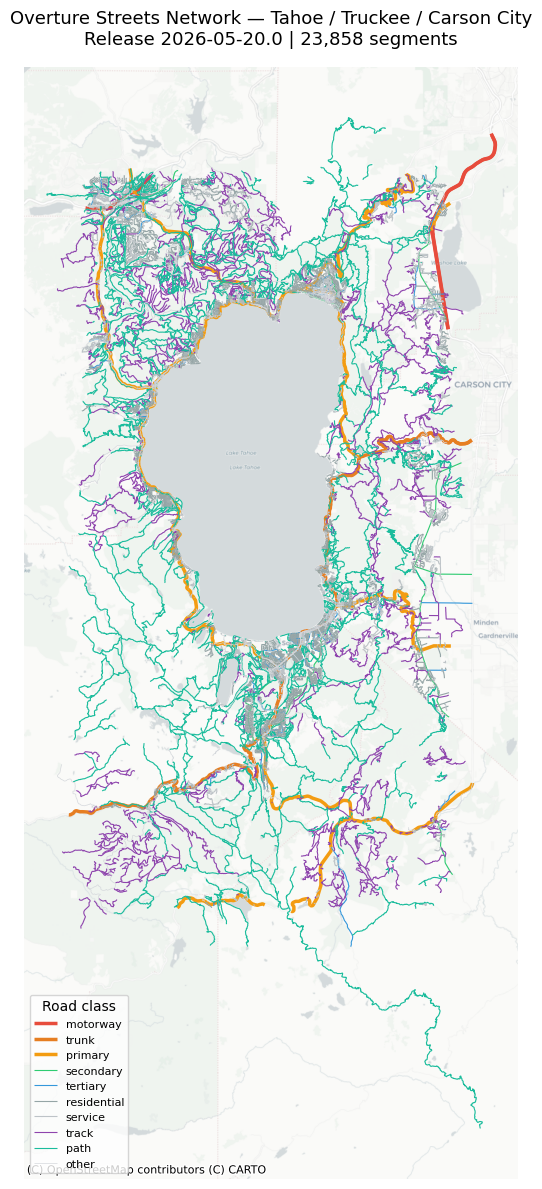

Map saved to tahoe_streets_overture.png


In [50]:
CLASS_COLORS = {
    'motorway':    '#e74c3c',
    'trunk':       '#e67e22',
    'primary':     '#f39c12',
    'secondary':   '#2ecc71',
    'tertiary':    '#3498db',
    'residential': '#95a5a6',
    'service':     '#bdc3c7',
    'track':       '#8e44ad',
    'path':        '#1abc9c',
}

segs_wm = segments_gdf.to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(14, 12))

for road_class, color in CLASS_COLORS.items():
    subset = segs_wm[segs_wm['class'] == road_class]
    if not subset.empty:
        lw = 2.5 if road_class in ('motorway', 'trunk', 'primary') else 0.8
        subset.plot(ax=ax, color=color, linewidth=lw, label=road_class)

other = segs_wm[~segs_wm['class'].isin(CLASS_COLORS)]
if not other.empty:
    other.plot(ax=ax, color='#d5d8dc', linewidth=0.5, label='other')

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)

ax.set_title(
    f'Overture Streets Network — Tahoe / Truckee / Carson City\n'
    f'Release {OVERTURE_RELEASE} | {len(segments_gdf):,} segments',
    fontsize=13
)
ax.legend(loc='lower left', fontsize=8, title='Road class')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_DIR / 'tahoe_streets_overture.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved to tahoe_streets_overture.png")

## 8. Export to GeoParquet and GeoJSON

In [51]:
segments_out   = OUT_DIR / f'tahoe_overture_segments_{OVERTURE_RELEASE}.parquet'
connectors_out = OUT_DIR / f'tahoe_overture_connectors_{OVERTURE_RELEASE}.parquet'

segments_gdf.to_parquet(segments_out, index=False)
connectors_gdf.to_parquet(connectors_out, index=False)

print(f"Segments   -> {segments_out}")
print(f"Connectors -> {connectors_out}")

Segments   -> tahoe_overture_segments_2026-05-20.0.parquet
Connectors -> tahoe_overture_connectors_2026-05-20.0.parquet


In [52]:
# GeoJSON of major roads only (keeps file size reasonable for ArcGIS/web tools)
major_classes = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary']
segments_major = segments_gdf[segments_gdf['class'].isin(major_classes)].copy()

geojson_out = OUT_DIR / f'tahoe_overture_segments_major_{OVERTURE_RELEASE}.geojson'
segments_major.to_file(geojson_out, driver='GeoJSON')

print(f"Major roads GeoJSON ({len(segments_major):,} features) -> {geojson_out}")

Major roads GeoJSON (1,780 features) -> tahoe_overture_segments_major_2026-05-20.0.geojson


## 8b. Export to Shapefiles via arcpy

Routes through a temp GeoJSON so arcpy can read it. Note: shapefile field names are capped at 10 characters — arcpy truncates automatically.

In [53]:
import arcpy
import pandas as pd
import numpy as np

def gdf_to_shapefile(gdf, out_shp):
    """Write a GeoDataFrame to a shapefile using arcpy.da.InsertCursor."""
    out_shp  = str(Path(out_shp).resolve())
    out_dir  = str(Path(out_shp).parent)
    out_name = Path(out_shp).name
    sr = arcpy.SpatialReference(4326)

    first_type = gdf.geometry.geom_type.dropna().iloc[0]
    geom_map = {
        'Point': 'POINT', 'MultiPoint': 'MULTIPOINT',
        'LineString': 'POLYLINE', 'MultiLineString': 'POLYLINE',
        'Polygon': 'POLYGON', 'MultiPolygon': 'POLYGON',
    }
    arcpy_type = geom_map.get(first_type, 'POLYLINE')

    if arcpy.Exists(out_shp):
        arcpy.management.Delete(out_shp)
    arcpy.management.CreateFeatureclass(out_dir, out_name, arcpy_type, spatial_reference=sr)

    reserved = {f.name.lower() for f in arcpy.ListFields(out_shp)}

    attr_cols = [c for c in gdf.columns if c != 'geometry']
    field_map = {}
    used = set(reserved)
    for col in attr_cols:
        base = col[:10]
        if base.lower() in used:
            for i in range(1, 100):
                candidate = f"{col[:8]}_{i}"[:10]
                if candidate.lower() not in used:
                    base = candidate
                    break
            else:
                print(f"  Skipping '{col}' — could not create unique field name")
                continue
        field_map[col] = base
        used.add(base.lower())

    for col, fname in field_map.items():
        if pd.api.types.is_float_dtype(gdf[col]):
            arcpy.management.AddField(out_shp, fname, 'DOUBLE',
                                      field_is_nullable='NULLABLE')
        elif pd.api.types.is_integer_dtype(gdf[col]):
            arcpy.management.AddField(out_shp, fname, 'LONG',
                                      field_is_nullable='NULLABLE')
        else:
            arcpy.management.AddField(out_shp, fname, 'TEXT',
                                      field_length=254,
                                      field_is_nullable='NULLABLE')

    mapped_cols   = list(field_map.keys())
    cursor_fields = [field_map[c] for c in mapped_cols] + ['SHAPE@WKT']

    is_float = {c: pd.api.types.is_float_dtype(gdf[c])   for c in mapped_cols}
    is_int   = {c: pd.api.types.is_integer_dtype(gdf[c]) for c in mapped_cols}

    with arcpy.da.InsertCursor(out_shp, cursor_fields) as cur:
        for _, row in gdf.iterrows():
            vals = []
            for col in mapped_cols:
                v = row[col]
                try:
                    null = pd.isna(v)
                except (TypeError, ValueError):
                    null = False
                if null:
                    # TEXT fields can't take None — use empty string
                    vals.append(None if (is_float[col] or is_int[col]) else '')
                elif is_float[col] or is_int[col]:
                    vals.append(v)
                else:
                    vals.append(str(v)[:254])
            vals.append(row.geometry.wkt if row.geometry is not None else None)
            cur.insertRow(vals)

    n = int(arcpy.management.GetCount(out_shp).getOutput(0))
    print(f"Exported {n:,} features  ->  {out_shp}")
    renamed = {k: v for k, v in field_map.items() if k != v}
    if renamed:
        print(f"  Renamed fields: {renamed}")

release_tag = OVERTURE_RELEASE.replace('.', '_').replace('-', '_')
seg_shp = str(OUT_DIR / f'tahoe_overture_segments_{release_tag}.shp')
con_shp = str(OUT_DIR / f'tahoe_overture_connectors_{release_tag}.shp')

gdf_to_shapefile(segments_gdf,   seg_shp)
gdf_to_shapefile(connectors_gdf, con_shp)

Exported 23,858 features  ->  C:\Users\amcclary\Documents\GitHub\Transportation\StreetNetwork\OvertureDownload\tahoe_overture_segments_2026_05_20_0.shp
  Renamed fields: {'id': 'id_1', 'speed_limit': 'speed_limi'}
Exported 33,821 features  ->  C:\Users\amcclary\Documents\GitHub\Transportation\StreetNetwork\OvertureDownload\tahoe_overture_connectors_2026_05_20_0.shp
  Renamed fields: {'id': 'id_1'}


## 8c. Export to File Geodatabase Feature Dataset via arcpy

Creates (or replaces) an `OvertureStreets` feature dataset inside `Streets_Network.gdb` and writes the segments (polylines) and connectors (points) as feature classes. GDB field names are not truncated to 10 characters like shapefiles.

In [ ]:
import arcpy
import pandas as pd
from pathlib import Path

GDB_PATH = r"F:\GIS\PROJECTS\Transportation\Streets Network\Streets_Network.gdb"
FDS_NAME = "OvertureStreets"
FDS_PATH = str(Path(GDB_PATH) / FDS_NAME)
SR_WGS84 = arcpy.SpatialReference(4326)

# Create feature dataset if it doesn't already exist
if not arcpy.Exists(FDS_PATH):
    arcpy.management.CreateFeatureDataset(GDB_PATH, FDS_NAME, SR_WGS84)
    print(f"Created feature dataset: {FDS_PATH}")
else:
    print(f"Feature dataset already exists: {FDS_PATH}")


def gdf_to_fc(gdf, fds_path, fc_name):
    """Write a GeoDataFrame to a GDB feature class inside a feature dataset."""
    fc_path = str(Path(fds_path) / fc_name)
    sr = arcpy.SpatialReference(4326)

    first_type = gdf.geometry.geom_type.dropna().iloc[0]
    geom_map = {
        "Point": "POINT", "MultiPoint": "MULTIPOINT",
        "LineString": "POLYLINE", "MultiLineString": "POLYLINE",
        "Polygon": "POLYGON", "MultiPolygon": "POLYGON",
    }
    arcpy_type = geom_map.get(first_type, "POLYLINE")

    if arcpy.Exists(fc_path):
        arcpy.management.Delete(fc_path)
    arcpy.management.CreateFeatureclass(fds_path, fc_name, arcpy_type, spatial_reference=sr)

    reserved = {f.name.lower() for f in arcpy.ListFields(fc_path)}
    attr_cols = [c for c in gdf.columns if c != "geometry"]

    field_map = {}
    used = set(reserved)
    for col in attr_cols:
        # GDB supports up to 64-char field names — no truncation needed
        base = col
        if base.lower() in used:
            for i in range(1, 100):
                candidate = f"{col}_{i}"
                if candidate.lower() not in used:
                    base = candidate
                    break
            else:
                print(f"  Skipping '{col}' — could not create unique field name")
                continue
        field_map[col] = base
        used.add(base.lower())

    for col, fname in field_map.items():
        if pd.api.types.is_float_dtype(gdf[col]):
            arcpy.management.AddField(fc_path, fname, "DOUBLE", field_is_nullable="NULLABLE")
        elif pd.api.types.is_integer_dtype(gdf[col]):
            arcpy.management.AddField(fc_path, fname, "LONG", field_is_nullable="NULLABLE")
        else:
            arcpy.management.AddField(fc_path, fname, "TEXT", field_length=254, field_is_nullable="NULLABLE")

    mapped_cols   = list(field_map.keys())
    cursor_fields = [field_map[c] for c in mapped_cols] + ["SHAPE@WKT"]

    is_float = {c: pd.api.types.is_float_dtype(gdf[c])   for c in mapped_cols}
    is_int   = {c: pd.api.types.is_integer_dtype(gdf[c]) for c in mapped_cols}

    with arcpy.da.InsertCursor(fc_path, cursor_fields) as cur:
        for _, row in gdf.iterrows():
            vals = []
            for col in mapped_cols:
                v = row[col]
                try:
                    null = pd.isna(v)
                except (TypeError, ValueError):
                    null = False
                if null:
                    vals.append(None if (is_float[col] or is_int[col]) else "")
                elif is_float[col] or is_int[col]:
                    vals.append(v)
                else:
                    vals.append(str(v)[:254])
            vals.append(row.geometry.wkt if row.geometry is not None else None)
            cur.insertRow(vals)

    n = int(arcpy.management.GetCount(fc_path).getOutput(0))
    print(f"Exported {n:,} features  ->  {fc_path}")
    renamed = {k: v for k, v in field_map.items() if k != v}
    if renamed:
        print(f"  Renamed fields: {renamed}")


# Prefix with "Overture_" — GDB requires unique FC names across the entire geodatabase,
# including across feature datasets. Generic names like "Segments" collide with existing FCs.
gdf_to_fc(segments_gdf,   FDS_PATH, "Overture_Segments")
gdf_to_fc(connectors_gdf, FDS_PATH, "Overture_Connectors")

## 9. Alternate Method: DuckDB via S3

Directly queries Overture's S3 bucket. Requires knowing the exact release string.
Update `OVERTURE_RELEASE` in cell 3 if needed — check https://docs.overturemaps.org/release/

In [ ]:
import duckdb

con = duckdb.connect()
con.execute("INSTALL httpfs;   LOAD httpfs;")
con.execute("INSTALL spatial; LOAD spatial;")
con.execute("SET s3_region = 'us-west-2';")

S3_SEGMENTS = (
    f"s3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/"
    "theme=transportation/type=segment/*"
)

duckdb_sql = f"""
SELECT
    id,
    subtype,
    class,
    geometry AS geom_wkt
FROM read_parquet('{S3_SEGMENTS}', filename=true, hive_partitioning=1)
WHERE bbox.xmin BETWEEN {BBOX['xmin']} AND {BBOX['xmax']}
  AND bbox.ymin BETWEEN {BBOX['ymin']} AND {BBOX['ymax']}
  AND subtype = 'road'
"""

# Uncomment to run:
# duckdb_df = con.execute(duckdb_sql).df()
# print(f"DuckDB result: {len(duckdb_df):,} rows")
print("DuckDB query ready — uncomment the last two lines to execute.")

## 10. Network Summary Stats

In [ ]:
segs_utm = segments_gdf.to_crs('EPSG:32610')
segs_utm['length_m'] = segs_utm.geometry.length

summary = (
    segs_utm.groupby('class')['length_m']
    .agg(count='count', total_km=lambda x: x.sum() / 1000)
    .sort_values('total_km', ascending=False)
    .reset_index()
)
summary['total_km'] = summary['total_km'].round(1)

print(f"Total network: {segs_utm['length_m'].sum() / 1000:.1f} km across {len(segs_utm):,} segments\n")
print(summary.to_string(index=False))

## 11. Topology Repair — Split & Snap for a Routable Network

Overture segments do **not** guarantee shared endpoint nodes. A segment may pass
through a connector at a mid-point (`at` ∈ (0, 1)), meaning two segments that
meet there don't actually share a coordinate unless you split the line at that
position first.

**Pipeline**

1. Extract `{connector_id, at}` refs from the raw `connectors` list column  
2. Split each segment at every interior connector position  
3. Snap the endpoints of each sub-edge to the connector's exact point coordinate  
4. Verify topology, then export `Edges_Routable` to the GDB

In [ ]:
# --- 11a. Extract connector attachment refs from raw PyArrow table ---
# The `connectors` column is a list of structs: {connector_id: str, at: float}
# `at` is the fractional position (0.0–1.0) along the segment's LineString.
# flatten_table() dropped this column; we read it directly from seg_table via
# to_pylist() which always returns plain Python dicts regardless of PyArrow version.

if 'connectors' not in seg_table.schema.names:
    raise RuntimeError(f"'connectors' not in schema. Found: {seg_table.schema.names}")

# Show the schema type and a sample entry so field names are visible
connectors_field = seg_table.schema.field('connectors')
print(f"connectors field type : {connectors_field.type}")

sample_entry = None
for val in seg_table['connectors'].to_pylist():
    if val:
        sample_entry = val
        break
print(f"Sample entry          : {sample_entry}")

def extract_connector_refs(seg_table_pa):
    ids  = seg_table_pa['id'].to_pylist()
    cons = seg_table_pa['connectors'].to_pylist()

    rows = []
    for seg_id, clist in zip(ids, cons):
        if not clist:
            continue
        for c in clist:
            if not isinstance(c, dict):
                continue
            cid = c.get('connector_id') or c.get('id')
            at  = c.get('at')
            if cid is not None and at is not None:
                rows.append({'segment_id': seg_id, 'connector_id': cid, 'at': float(at)})
    return pd.DataFrame(rows, columns=['segment_id', 'connector_id', 'at'])

conn_refs = extract_connector_refs(seg_table)
print(f"\nConnector–segment attachment records : {len(conn_refs):,}")

interior = conn_refs[(conn_refs['at'] > 1e-8) & (conn_refs['at'] < 1 - 1e-8)]
print(f"Interior attachments (require split) : {len(interior):,}")
print(f"Unique segments with at least one ref: {conn_refs['segment_id'].nunique():,}")
conn_refs.head(6)

connectors field type : list<element: struct<connector_id: string, at: double>>
Sample entry          : [{'connector_id': '2203954f-dcbd-47ef-a9a7-679e76bf8d34', 'at': 0.0}, {'connector_id': 'bdcdda3d-348e-4d18-891e-d06a624ba774', 'at': 0.131484328}, {'connector_id': '3936f458-10bc-4abf-9036-7784749382d1', 'at': 0.987034329}, {'connector_id': '2de9146f-05eb-4fb3-a9e3-6c6972ef6bd8', 'at': 1.0}]

Connector–segment attachment records : 64,764
Interior attachments (require split) : 18,709
Unique segments with at least one ref: 23,027


,segment_id,connector_id,at
0,33668e39-a095-4152-8a4e-ade0e3eb52e1,2203954f-dcbd-47ef-a9a7-679e76bf8d34,0.000000
1,33668e39-a095-4152-8a4e-ade0e3eb52e1,bdcdda3d-348e-4d18-891e-d06a624ba774,0.131484
2,33668e39-a095-4152-8a4e-ade0e3eb52e1,3936f458-10bc-4abf-9036-7784749382d1,0.987034
3,33668e39-a095-4152-8a4e-ade0e3eb52e1,2de9146f-05eb-4fb3-a9e3-6c6972ef6bd8,1.000000
4,901d73be-abfe-435a-becd-320c3913fe39,44c65b71-7509-41aa-b8eb-0c41396b939d,0.000000
5,901d73be-abfe-435a-becd-320c3913fe39,442e3f1a-1af2-4e3c-8f7e-c7a1616b0c35,1.000000


In [ ]:
# --- 11b. Split each segment at all connector positions ---
from shapely.ops import substring
from shapely.geometry import LineString, MultiLineString

def split_at_positions(geom, at_values):
    """
    Split a LineString at normalized fractional positions (0–1).
    Returns list of (sub_geom, from_at, to_at).
    Handles MultiLineString by operating on the first component only (rare in Overture).
    """
    if isinstance(geom, MultiLineString):
        geom = list(geom.geoms)[0]

    cuts = sorted({0.0} | {float(v) for v in at_values} | {1.0})
    pieces = []
    for i in range(len(cuts) - 1):
        a, b = cuts[i], cuts[i + 1]
        if b - a < 1e-9:
            continue
        sub = substring(geom, a, b, normalized=True)
        if sub is not None and not sub.is_empty and len(sub.coords) >= 2:
            pieces.append((sub, a, b))
    return pieces or [(geom, 0.0, 1.0)]

# Build at-value → connector_id lookup per segment
refs_grouped = conn_refs.groupby('segment_id')
seg_index    = segments_gdf.set_index('id')

edge_rows = []

for seg_id, group in refs_grouped:
    if seg_id not in seg_index.index:
        continue

    geom    = seg_index.at[seg_id, 'geometry']
    at_vals = group['at'].tolist()
    # round to avoid floating-point key misses
    at_to_con = {round(float(r.at), 10): r.connector_id for r in group.itertuples()}

    for sub_geom, from_at, to_at in split_at_positions(geom, at_vals):
        edge_rows.append({
            'segment_id':     seg_id,
            'from_connector': at_to_con.get(round(from_at, 10)),
            'to_connector':   at_to_con.get(round(to_at,   10)),
            'from_at':        from_at,
            'to_at':          to_at,
            'geometry':       sub_geom,
        })

# Segments with no connector refs — keep as-is (dead ends, isolated paths)
segs_with_refs = set(refs_grouped.groups) & set(seg_index.index)
segs_no_refs   = set(seg_index.index) - segs_with_refs
for seg_id in segs_no_refs:
    edge_rows.append({
        'segment_id':     seg_id,
        'from_connector': None,
        'to_connector':   None,
        'from_at':        0.0,
        'to_at':          1.0,
        'geometry':       seg_index.at[seg_id, 'geometry'],
    })

edges_gdf = gpd.GeoDataFrame(edge_rows, geometry='geometry', crs=segments_gdf.crs)
print(f"Raw segments  : {len(segments_gdf):,}")
print(f"Edges (split) : {len(edges_gdf):,}  (+{len(edges_gdf) - len(segments_gdf):,} from interior splits)")
edges_gdf[['segment_id', 'from_connector', 'to_connector', 'from_at', 'to_at']].head(6)

Raw segments  : 23,002
Edges (split) : 41,667  (+18,665 from interior splits)


,segment_id,from_connector,to_connector,from_at,to_at
0,00072370-cbb0-42df-87ee-37b2fbaf54e2,b4c98fc9-2cda-40e2-9301-b44fa20b8c11,1acab012-4623-42c6-8d4d-f3d7e7ada11c,0.0,1.0
1,00087cd0-c1fc-4964-be81-5d0526936c3b,8d6dc841-9a07-47f3-9e53-282c72ea3563,fd815b3c-185d-49e3-abac-47eb4a123738,0.0,1.0
2,000c2af2-5870-4c54-9b17-7beac334e4f3,ed55be2f-719f-443d-9840-2f7b3e295ba8,2376bd4a-ccb9-4aae-8b53-69a9d940f364,0.0,1.0
3,0010ba7d-a8e5-444b-a4e5-18d5b8f39233,6a32b15c-aaf1-49af-9e71-b14e1747cf99,efa58f71-2376-4905-91e5-8463e26e6dd8,0.0,1.0
4,00125f81-919e-4f6c-810c-a90ee803fabb,f28326fe-c635-46ce-82e7-fae594a3b1cb,7ef8c432-c41d-434b-a8ef-a8d6606c8ef2,0.0,1.0
5,001282e0-a72c-4181-af91-033a02fada60,a0e4cce5-b1ce-4316-858e-d690313e89ba,e3dc9328-60d3-4bf1-9564-7ba51543ed53,0.0,1.0


In [ ]:
# --- 11c. Snap endpoints to connector point coordinates ---
# Coordinate rounding during Overture encoding can leave sub-millimeter gaps
# between a segment endpoint and its declared connector point. Replace the
# first/last vertex with the connector's exact Point geometry.

con_point_lookup = connectors_gdf.set_index('id')['geometry'].to_dict()

def snap_endpoints(geom, from_con, to_con, lookup):
    coords = list(geom.coords)
    if from_con and from_con in lookup:
        pt = lookup[from_con]
        coords[0] = (pt.x, pt.y)
    if to_con and to_con in lookup:
        pt = lookup[to_con]
        coords[-1] = (pt.x, pt.y)
    return LineString(coords) if len(coords) >= 2 else geom

edges_gdf['geometry'] = edges_gdf.apply(
    lambda r: snap_endpoints(r.geometry, r.from_connector, r.to_connector, con_point_lookup),
    axis=1,
)
edges_gdf = edges_gdf.set_geometry('geometry')
print("Endpoints snapped.")

# Join road attributes from segments
attr_cols = [c for c in ['class', 'name', 'surface', 'speed_limit'] if c in segments_gdf.columns]
edges_gdf = edges_gdf.merge(
    segments_gdf[['id'] + attr_cols].rename(columns={'id': 'segment_id'}),
    on='segment_id', how='left',
)

# Edge length in meters (project to UTM for accuracy)
edges_utm = edges_gdf.to_crs('EPSG:32610')
edges_gdf['length_m'] = edges_utm.geometry.length.round(2)

print(f"Final edge table: {len(edges_gdf):,} edges")
print(edges_gdf[['segment_id', 'from_connector', 'to_connector', 'length_m', 'class']].head(6))

Endpoints snapped.
Final edge table: 41,667 edges
                             segment_id                        from_connector  \
0  00072370-cbb0-42df-87ee-37b2fbaf54e2  b4c98fc9-2cda-40e2-9301-b44fa20b8c11   
1  00087cd0-c1fc-4964-be81-5d0526936c3b  8d6dc841-9a07-47f3-9e53-282c72ea3563   
2  000c2af2-5870-4c54-9b17-7beac334e4f3  ed55be2f-719f-443d-9840-2f7b3e295ba8   
3  0010ba7d-a8e5-444b-a4e5-18d5b8f39233  6a32b15c-aaf1-49af-9e71-b14e1747cf99   
4  00125f81-919e-4f6c-810c-a90ee803fabb  f28326fe-c635-46ce-82e7-fae594a3b1cb   
5  001282e0-a72c-4181-af91-033a02fada60  a0e4cce5-b1ce-4316-858e-d690313e89ba   

                           to_connector  length_m        class  
0  1acab012-4623-42c6-8d4d-f3d7e7ada11c     51.47  residential  
1  fd815b3c-185d-49e3-abac-47eb4a123738     50.42  residential  
2  2376bd4a-ccb9-4aae-8b53-69a9d940f364     48.94      service  
3  efa58f71-2376-4905-91e5-8463e26e6dd8     15.67      service  
4  7ef8c432-c41d-434b-a8ef-a8d6606c8ef2     24.95      se

In [ ]:
# --- 11d. Topology verification ---

both_known = edges_gdf['from_connector'].notna() & edges_gdf['to_connector'].notna()
from_only  = edges_gdf['from_connector'].notna() & edges_gdf['to_connector'].isna()
neither    = edges_gdf['from_connector'].isna()   & edges_gdf['to_connector'].isna()

print("=== Topology check ===")
print(f"  Both endpoints have a connector : {both_known.sum():>7,}  ({100*both_known.mean():.1f}%)")
print(f"  From only (dead-end tail)       : {from_only.sum():>7,}")
print(f"  No connector refs               : {neither.sum():>7,}  (isolated / no-ref segments)")

all_cons = pd.concat([
    edges_gdf['from_connector'].dropna().rename('connector_id'),
    edges_gdf['to_connector'].dropna().rename('connector_id'),
])
degree = all_cons.value_counts()
print(f"\n=== Node degree distribution ===")
print(degree.value_counts().sort_index().rename_axis('degree').rename('nodes').to_string())

# GeoParquet
edges_out = OUT_DIR / f'tahoe_overture_edges_{OVERTURE_RELEASE}.parquet'
edges_gdf.to_parquet(edges_out, index=False)
print(f"\nEdges (routable) -> {edges_out}")

In [ ]:
# --- 11e. Export routable edges to GDB feature dataset ---
import arcpy

gdf_to_fc(edges_gdf, FDS_PATH, "Overture_Edges_Routable")